# Quick Commerce Market Analytics

## Data Analysis using Python

**Author:** C.S.Rachel

### Project Objective

This project analyzes quick commerce transactional data to understand company performance, customer purchasing behavior, delivery efficiency, and product trends. The analysis includes data inspection, cleaning, exploratory analysis, and key business insights before dashboard development in Tableau.

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#Load Dataset
df = pd.read_csv(r"C:\Users\admin\Documents\Quick-Commerce-Market-Analytics\dataset\quick_commerce.csv")

In [7]:
#Display First Records
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [8]:
#Dataset Shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 947752
Columns: 13


In [9]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947752 entries, 0 to 947751
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  int64  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 94.0+ MB


In [10]:
#Statistical Summary
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912008,16.506620,7.750048,10.313292,3.042655,0.400786,3.800295
std,2.887273e+05,12.118982,374.175332,6.340851,4.187153,5.630770,1.202499,0.490058,0.718762
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.000000
25%,1.249939e+06,28.000000,288.000000,12.000000,4.100000,5.000000,2.000000,0.000000,3.000000
50%,1.500026e+06,38.000000,532.000000,16.000000,7.800000,10.000000,3.000000,0.000000,4.000000
75%,1.750145e+06,49.000000,797.000000,20.000000,11.400000,15.000000,4.000000,1.000000,4.000000
max,2.000000e+06,59.000000,2492.000000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [11]:
#Missing Values
df.isnull().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

In [12]:
#Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
#Check Data Types
df.dtypes

Order_ID                     int64
Company                     object
City                        object
Customer_Age                 int64
Order_Value                  int64
Delivery_Time_Min            int64
Distance_Km                float64
Items_Count                  int64
Product_Category            object
Payment_Method              object
Customer_Rating              int64
Discount_Applied             int64
Delivery_Partner_Rating      int64
dtype: object

In [14]:
#Unique Values
print(df["Company"].unique())
print(df["Payment_Method"].unique())
print(df["Product_Category"].unique())

['Swiggy Instamart' 'Flipkart Minutes' 'Dunzo' 'Jio Mart' 'Blinkit'
 'Amazon Now' 'Big Basket' 'Zepto']
['Wallet' 'Cash on Delivery' 'Credit Card' 'UPI' 'Debit Card']
['Dairy' 'Snacks' 'Personal Care' 'Household' 'Beverages' 'Groceries'
 'Fruits & Vegetables']


Exploratory Analysis

In [15]:
#Revenue by Company
company_revenue = df.groupby("Company")["Order_Value"].sum().sort_values(ascending=False)

print(company_revenue)

Company
Swiggy Instamart    76407756
Blinkit             72499575
Zepto               70339672
Big Basket          67884762
Flipkart Minutes    66998289
Amazon Now          65832504
Dunzo               64007579
Jio Mart            57112860
Name: Order_Value, dtype: int64


In [16]:
#Orders by Company
company_orders = df["Company"].value_counts()

print(company_orders)

Company
Flipkart Minutes    118965
Blinkit             118887
Zepto               118565
Swiggy Instamart    118475
Dunzo               118463
Jio Mart            118267
Amazon Now          118083
Big Basket          118047
Name: count, dtype: int64


In [17]:
#Average Customer Rating
df.groupby("Company")["Customer_Rating"].mean()

Company
Amazon Now          2.913417
Big Basket          3.097902
Blinkit             3.580762
Dunzo               2.428024
Flipkart Minutes    3.016316
Jio Mart            2.819747
Swiggy Instamart    3.279443
Zepto               3.203062
Name: Customer_Rating, dtype: float64

In [18]:
#Average Delivery Time
df.groupby("Company")["Delivery_Time_Min"].mean()

Company
Amazon Now          18.984155
Big Basket          18.027345
Blinkit             15.121771
Dunzo               14.177060
Flipkart Minutes    17.045080
Jio Mart            23.013224
Swiggy Instamart    16.072690
Zepto                9.644313
Name: Delivery_Time_Min, dtype: float64

In [19]:
#Product Category Distribution
df["Product_Category"].value_counts()

Product_Category
Dairy                  136320
Groceries              135715
Snacks                 135391
Household              135374
Beverages              135294
Personal Care          135240
Fruits & Vegetables    134418
Name: count, dtype: int64

In [20]:
#Payment Method Distribution
df["Payment_Method"].value_counts()

Payment_Method
Cash on Delivery    190278
Credit Card         189570
Debit Card          189446
UPI                 189420
Wallet              189038
Name: count, dtype: int64

In [21]:
#Customer Age Distribution
df["Customer_Age"].describe()

count    947752.000000
mean         38.471165
std          12.118982
min          18.000000
25%          28.000000
50%          38.000000
75%          49.000000
max          59.000000
Name: Customer_Age, dtype: float64

Basic Visualizations

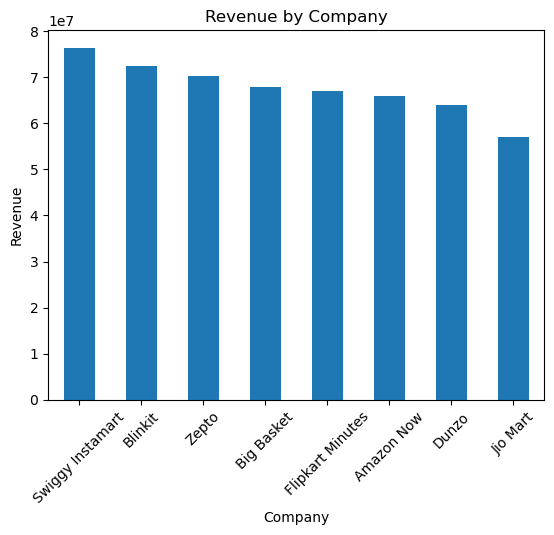

In [22]:
#Revenue by Company
company_revenue.plot(kind="bar")

plt.title("Revenue by Company")
plt.xlabel("Company")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [26]:
# Insight:
# Swiggy Instamart generated the highest revenue among the companies analyzed.

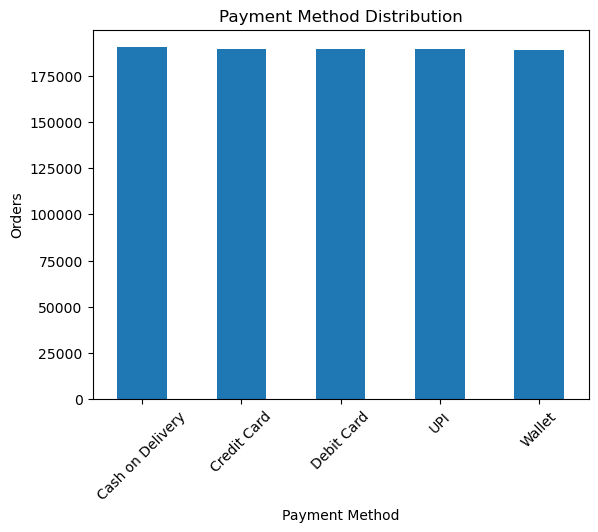

In [24]:
#Payment Method Distribution
df["Payment_Method"].value_counts().plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.show()

In [29]:
# Insight:
# Cash on Delivery was the most commonly used payment method.

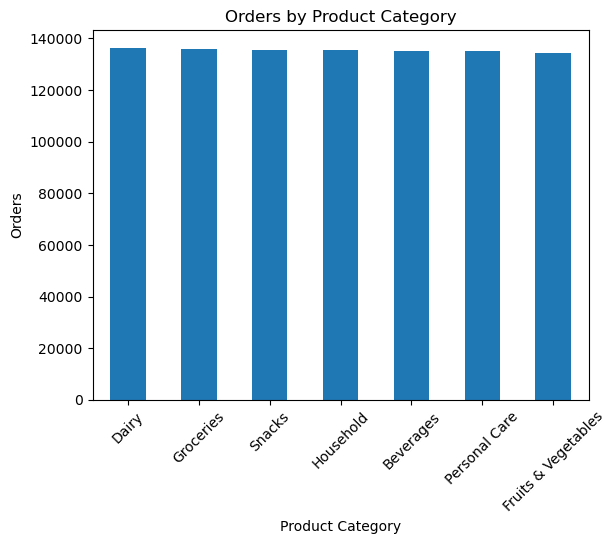

In [23]:
#Product Category Distribution
df["Product_Category"].value_counts().plot(kind="bar")

plt.title("Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.show()

In [28]:
# Insight:
# Dairy products accounted for the highest order volume.

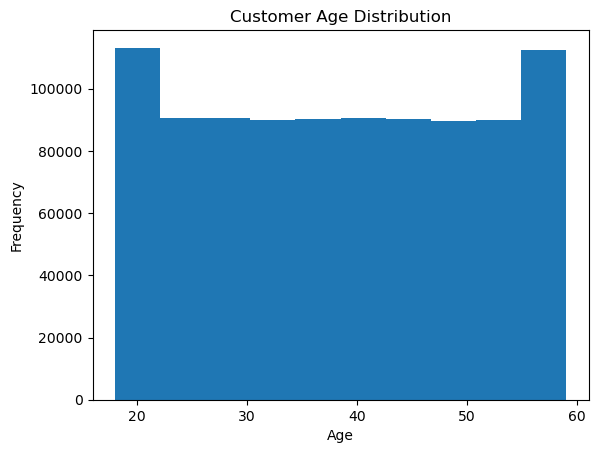

In [25]:
#Customer Age Distribution
plt.hist(df["Customer_Age"], bins=10)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# Key Insights

• Company performance varies based on revenue and average order value.

• Certain product categories contribute significantly more orders than others.

• Digital payment methods are widely used by customers.

• Delivery time differs across companies, indicating operational differences.

• Customer ratings provide useful information for evaluating service quality.

These findings supported the creation of interactive Tableau dashboards and business recommendations.